# Joint ATAC–RNA factorization with learned loading priors

This is the corrected **fully coupled ATAC/RNA joint sampler**. The single-matrix
`cEBMF` interface also selects joint sampling when a self-covariate flag is enabled.
It models $A_k\mid A_{<k},X$ and $R_j\mid A,R_{<j},X$, and samples HMM feature factors.
Loading moves include every direct child's prior contribution. EMDN children contribute
changes in their means and variances as well as their weights.

The default quick run has 400 samples and 200 features. Set `QUICK=False` for the original
2,000 × 1,000 simulation. The full-size CGB run took about three minutes on the development CPU.
The default includes 60% paired rows, 20% ATAC-only rows, and 20% RNA-only rows.
Set `UNPAIRED_FRACTION=0` to keep every row paired.

Install the current checkout using `python -m pip install -e .`, then restart the kernel.
Select your `cebmf` Python environment. The terminal equivalent is
`python examples/run_atac_rna_joint.py --quick` from the repository root.

In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

# Works when Jupyter starts from the repository root or its examples folder.
root = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "examples" / "run_atac_rna_joint.py").exists()), None)
if root is None:
    raise RuntimeError("Open this notebook from inside the cebmf_torch checkout.")
sys.path.insert(0, str(root / "examples"))
from run_atac_rna_joint import run_example
from cebmf_torch.experimental.conditional import SCALAR_PRIORS

print("Python:", sys.executable)
print("Supported loading priors:", SCALAR_PRIORS)

Python: C:\Users\willi\miniconda3\envs\cebmf\python.exe
Supported loading priors: ('cgb', 'cgb_sharp', 'cgb_sharp_2', 'cash', 'lcash', 'po_lcash', 'emdn', 'spiked_emdn')


In [2]:
QUICK = True
PRIOR_ATAC = "cgb"
PRIOR_RNA = "cgb"  # Also try spiked_emdn, emdn, cash, lcash, po_lcash, cgb_sharp, cgb_sharp_2.
UNPAIRED_FRACTION = 0.2  # Fraction exclusive to EACH view; must be < 0.5.
USE_SIDE_INFO = False   # True generates observed context before the loadings.
SEED = 1

settings = dict(n=400, p=200, rounds=3, burnin=40, draws=40, thin=1) if QUICK else dict(
    n=2000, p=1000, rounds=8, burnin=100, draws=100, thin=2
)

## What this run does

The simulation preserves the original two independent ATAC bits and the RNA profiles
for ATAC states 01, 10, 11 and 00. At 1,000 features, the signal bands are exactly
`200:250`, `500:550` and `700:750`. Noise SD is 1.5 in both views.
If side information is enabled, observed Gaussian covariates instead govern the ATAC
activation probabilities; they are generated before the latent variables.

The helper deliberately reorders RNA rows and aligns the modalities by sample ID.
It also withholds 2% of otherwise observed entries for prediction diagnostics.
Missing measurements have no likelihood contribution. Their loadings remain latent,
and fixed side information is kept finite. **No simulated truth is supplied to the solver.**

Independent `gbinary`/HMM fits initialize the factor count and HMM parameters. A short
Monte Carlo EM phase then learns the loading priors from joint latent draws. Finally,
parameters are frozen, burn-in is discarded, and posterior draws are collected.
Noise, HMM parameters, scaling, ordering and factor counts stay fixed; this is joint
latent inference conditional on fitted parameters, not fully Bayesian parameter inference.

In [3]:
sim, data, solver, posterior, report = run_example(
    seed=SEED,
    prior_atac=PRIOR_ATAC,
    prior_rna=PRIOR_RNA,
    unpaired_fraction=UNPAIRED_FRACTION,
    use_side_info=USE_SIDE_INFO,
    holdout_fraction=0.02,
    **settings,
)
print(f"Elapsed: {report['total_seconds']:.1f} seconds")
print("Retained ranks:", report["ranks"])
print("Posterior row order is given by posterior.row_ids.")

Initializing 400 union rows, 200 features/view; priors cgb, cgb...
Retained ranks: ATAC 2, RNA 3. Learning loading priors...
Prior-learning round 1/3
Prior-learning round 2/3
Prior-learning round 3/3
Joint sweep 25/80; kept 0 draws
Joint sweep 50/80; kept 10 draws
Joint sweep 75/80; kept 35 draws
Elapsed: 17.3 seconds
Retained ranks: [2, 3]
Posterior row order is given by posterior.row_ids.


## Reconstruction diagnostics

The signal MSE below uses simulated noiseless data **only for evaluation**.
The independent reference is the initial `gbinary` fit, whereas the joint fit uses the
chosen conditional prior. This is a useful diagnostic, but it changes both the family
and inference method and is not a controlled ablation of the child correction.
Held-out-entry MSE is against noisy measurements never used for fitting.

The saved full-size seed-1 CGB run improved paired-row signal MSE for both views
(ATAC: 0.00089 → 0.00026; RNA: 0.00127 → 0.00039), but worsened both observed
unpaired groups. Partial overlap is supported; improvement is not guaranteed.
Those numbers describe one short run, not a benchmark or convergence claim.

In [4]:
for metric in report["metrics"]:
    noisy = metric["rows"] == "held_out_entries"
    key = "noisy" if noisy else "signal"
    baseline = metric[f"independent_{key}_mse"]
    baseline_text = "not available" if baseline is None else f"{baseline:.6f}"
    print(f"{metric['modality'].upper():4s} {metric['rows']:19s} n={metric['n']:6d}  "
          f"joint {key} MSE={metric[f'joint_{key}_mse']:.6f}  independent={baseline_text}")

ATAC paired              n=   240  joint signal MSE=0.008159  independent=0.010614
ATAC observed_unpaired   n=    80  joint signal MSE=0.011795  independent=0.010078
ATAC missing_modality    n=    80  joint signal MSE=0.013565  independent=not available
ATAC held_out_entries    n=  1262  joint noisy MSE=2.301971  independent=2.306099
RNA  paired              n=   240  joint signal MSE=0.010732  independent=0.016275
RNA  observed_unpaired   n=    80  joint signal MSE=0.010362  independent=0.010826
RNA  missing_modality    n=    80  joint signal MSE=0.021167  independent=not available
RNA  held_out_entries    n=  1294  joint noisy MSE=2.324518  independent=2.327774


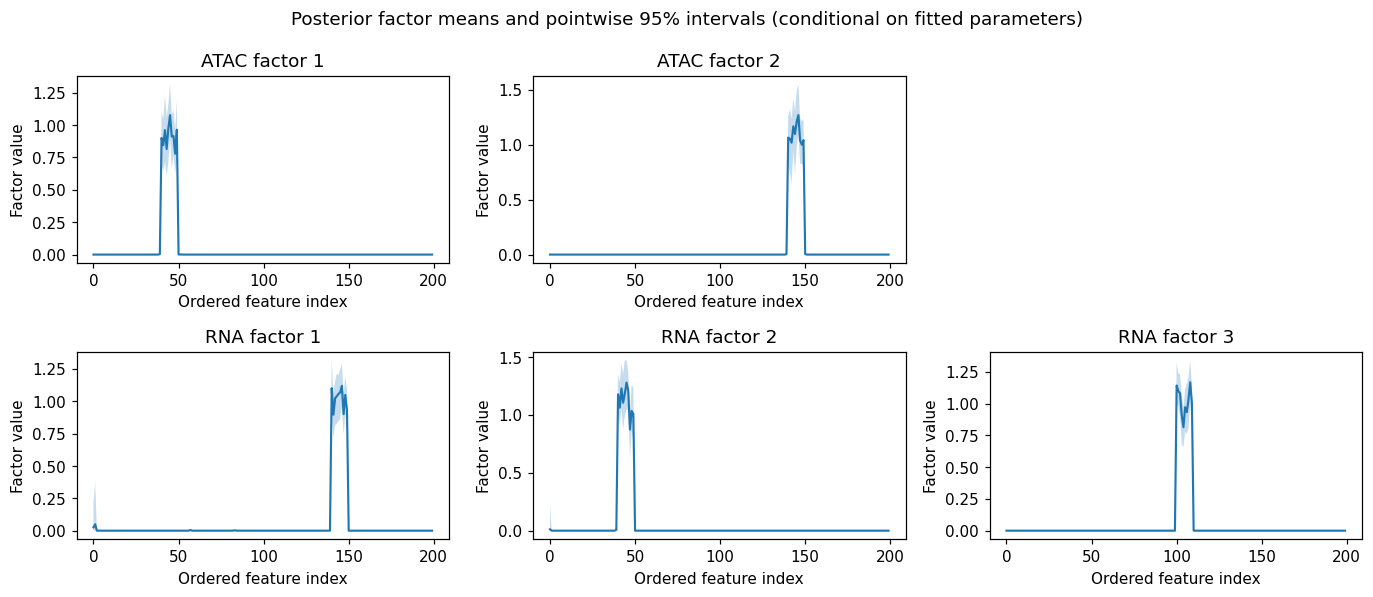

In [5]:
rank = max(posterior.atac.F.shape[1], posterior.rna.F.shape[1])
fig, axes = plt.subplots(2, rank, figsize=(4.2 * rank, 5.5), squeeze=False)
for row, (name, result) in enumerate((("ATAC", posterior.atac), ("RNA", posterior.rna))):
    for k, ax in enumerate(axes[row]):
        if k >= result.F.shape[1]:
            ax.set_visible(False)
            continue
        lo, hi = result.factor_draws[:, :, k].quantile(torch.tensor([0.025, 0.975], dtype=torch.float64), dim=0)
        ax.fill_between(range(result.F.shape[0]), lo.numpy(), hi.numpy(), alpha=0.25)
        ax.plot(result.F[:, k].numpy(), lw=1.4)
        ax.set(title=f"{name} factor {k + 1}", xlabel="Ordered feature index", ylabel="Factor value")
fig.suptitle("Posterior factor means and pointwise 95% intervals (conditional on fitted parameters)")
fig.tight_layout()
plt.show()

## An RNA-only row

For a missing ATAC row, the model integrates unknown ATAC loadings:

$$p(R_i\mid Y_i^R,X_i)\propto p(Y_i^R\mid R_i,F^R)
\int p(R_i\mid A_i,X_i)p(A_i\mid X_i)\,dA_i.$$

The marginal prior depends on fixed side information and the learned population
relationship. It is not obtained by filling missing ATAC loadings with zero or
removing the ATAC network inputs. RNA evidence can inform the missing ATAC state.
Some paired samples are required by this prototype; zero overlap generally cannot
identify the cross-modality relationship without additional assumptions.

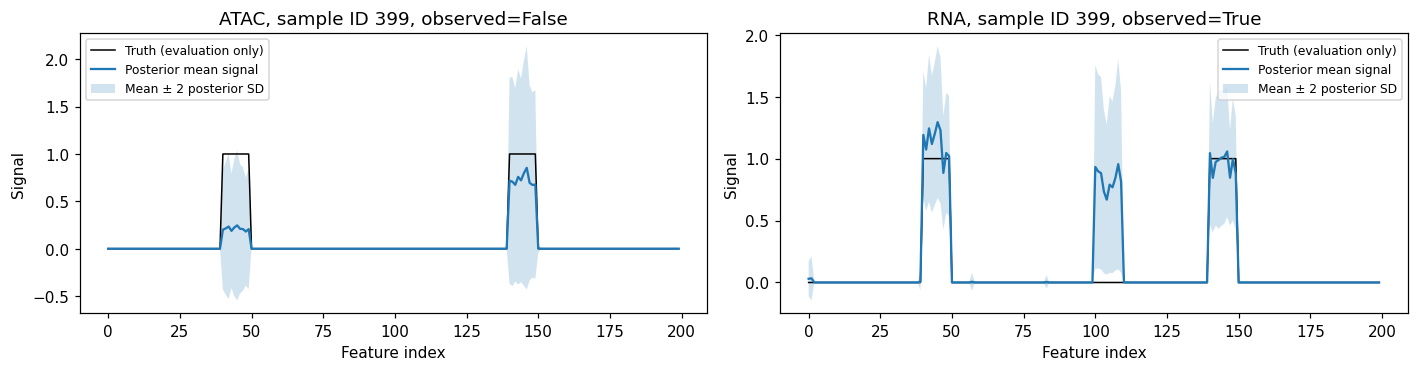

In [6]:
rna_only = (~data.atac_observed & data.rna_observed).nonzero().flatten()
row = int(rna_only[0]) if len(rna_only) else 0
original_id = data.ids[row]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, name, result in zip(axes, ("atac", "rna"), (posterior.atac, posterior.rna)):
    ax.plot(sim[f"signal_{name}"][original_id].numpy(), color="black", lw=1, label="Truth (evaluation only)")
    ax.plot(result.reconstruction[row].numpy(), label="Posterior mean signal")
    ax.fill_between(range(result.F.shape[0]),
                    (result.reconstruction[row] - 2 * result.reconstruction_sd[row]).numpy(),
                    (result.reconstruction[row] + 2 * result.reconstruction_sd[row]).numpy(),
                    alpha=0.2, label="Mean ± 2 posterior SD")
    observed = data.atac_observed[row] if name == "atac" else data.rna_observed[row]
    ax.set(title=f"{name.upper()}, sample ID {original_id}, observed={bool(observed)}",
           xlabel="Feature index", ylabel="Signal")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# Correct joint posterior reconstruction: average L @ F.T within each draw.
# posterior.rna.L @ posterior.rna.F.T generally gives a different answer.

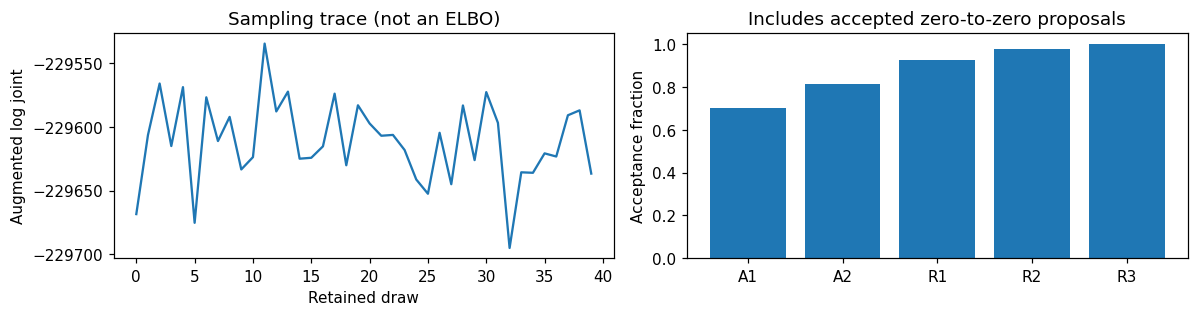

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(posterior.log_joint)
axes[0].set(xlabel="Retained draw", ylabel="Augmented log joint", title="Sampling trace (not an ELBO)")
labels = [f"A{k+1}" for k in range(solver.ka)] + [f"R{k+1}" for k in range(solver.kr)]
axes[1].bar(labels, posterior.acceptance.numpy())
axes[1].set(ylim=(0, 1.05), ylabel="Acceptance fraction", title="Includes accepted zero-to-zero proposals")
fig.tight_layout()
plt.show()

## Using your own data

Use `from cebmf_torch.experimental import JointATACRNA, align_modalities` and align
`X_obs_ATAC` and `X_obs_RNA` using their true sample IDs. Then construct
`JointATACRNA(aligned, prior_atac="cgb", prior_rna="spiked_emdn", ...)`, call
`fit_prior_parameters(...)`, and call `sample(...)`. Separate `cEBMF` calls treat supplied cross-modality covariates as fixed.
Use this coupled class for joint uncertainty and feedback between modalities.

This prototype exposes all eight scalar learned families. HMM factors support
`factor_prior="hmm"`, `"hmm_pos"` and `"hmm_neg"`. Sharp variants keep narrow
scales fixed by default. The experimental prior kwargs describe distributions;
they do not accept the legacy EBNM training `penalty`. Consult
`docs/source/joint_inference.rst` for configuration and limitations.

More sampling and multiple chains targeting the **same fitted parameters** are
needed to assess mixing. Intervals exclude parameter uncertainty and observation
noise. Network overfitting, ordering, initialization and misspecification still matter.

The manuscript contains general augmented variational updates and score-based
alternatives. The current implementation uses the sampler and exposes exact
within-component scores via autograd; it does not implement a learned score or VI optimizer.

Run correctness checks from the repository root:

```sh
python -m pytest tests/test_joint_conditional.py tests/test_joint_atac_rna.py -q
```